# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam

Notebook ini akan mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Kita akan membandingkan berbagai jenis *gait* untuk *quadruped* (Trot, Crawl) dan merancang *Tripod Gait* untuk *Hexapod*.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("Environment siap!")

Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

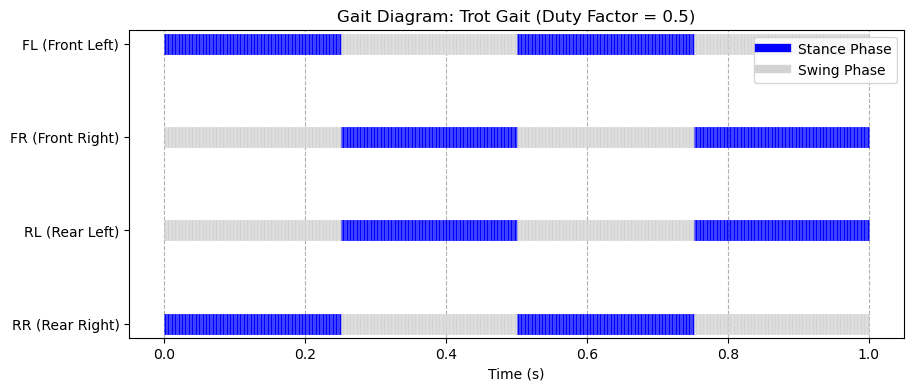

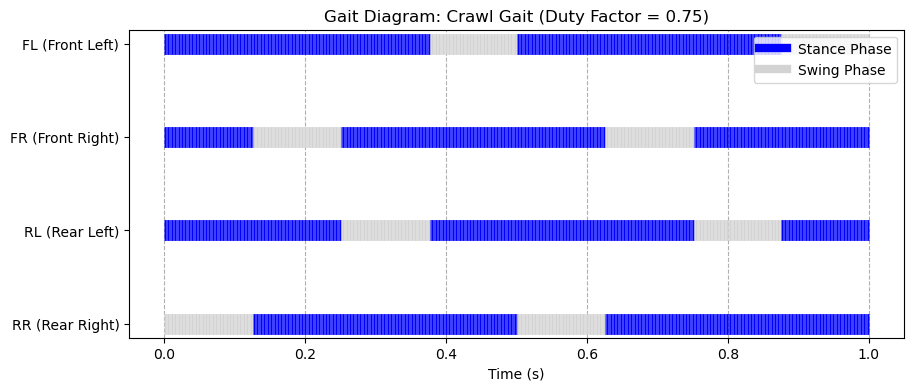

In [8]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')

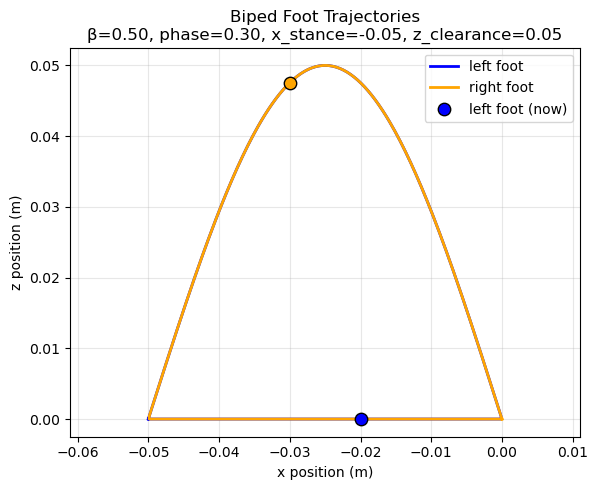

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

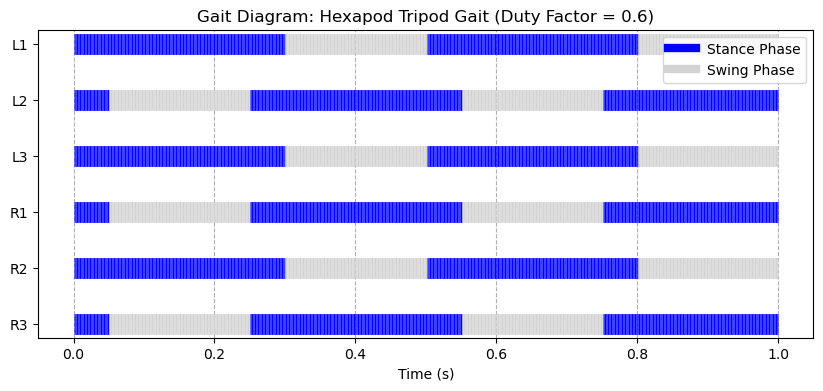

Minimum jumlah kaki di stance setiap waktu: 3
Verifikasi stabilitas: Stabil


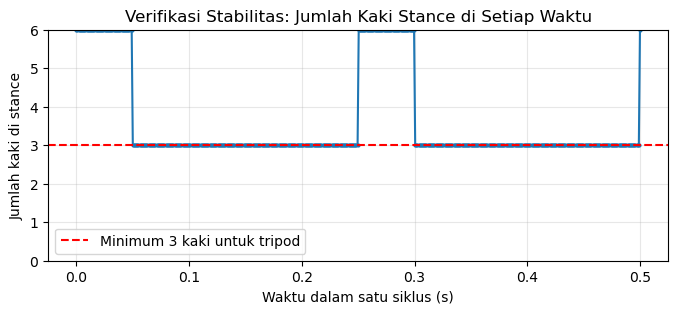

In [10]:
# TODO: Implementasikan Hexapod Tripod Gait Anda di bawah ini
hexapod_legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

class HexapodTripodGaitScheduler(QuadrupedGaitScheduler):
    def __init__(self, T=1.0):
        self.T = T
        self.legs = hexapod_legs

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500)
        fig, ax = plt.subplots(figsize=(10, 4))

        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = np.where(phases < duty_factor, 1, 0)
            for t_idx in range(len(time_steps) - 1):
                color = 'blue' if stance[t_idx] == 1 else 'lightgray'
                ax.plot([time_steps[t_idx], time_steps[t_idx + 1]],
                        [len(self.legs) - 1 - i, len(self.legs) - 1 - i],
                        color=color, lw=15, solid_capstyle='butt')

        ax.set_yticks(list(range(len(self.legs))))
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6),
                        plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')
        plt.show()

    def verify_stability(self, duty_factor, offsets):
        time_steps = np.linspace(0, self.T, 500)
        stance_matrix = np.zeros((len(self.legs), len(time_steps)), dtype=int)
        for i, offset in enumerate(offsets):
            phases = self.get_phase(time_steps, offset)
            stance_matrix[i, :] = np.where(phases < duty_factor, 1, 0)

        stance_count = stance_matrix.sum(axis=0)
        min_stance = stance_count.min()
        stable = min_stance >= 3
        print(f'Minimum jumlah kaki di stance setiap waktu: {min_stance}')
        print('Verifikasi stabilitas:', 'Stabil' if stable else 'Tidak stabil')
        return stable, stance_count

hex_scheduler = HexapodTripodGaitScheduler(T=0.5)
hexapod_offsets = [0.0, 0.5, 0.0, 0.5, 0.0, 0.5]  # [L1, L2, L3, R1, R2, R3]
hexapod_duty_factor = 0.60

hex_scheduler.plot_gait_diagram(duty_factor=hexapod_duty_factor,
                                offsets=hexapod_offsets,
                                title='Hexapod Tripod Gait')

stable, stance_count = hex_scheduler.verify_stability(hexapod_duty_factor,
                                                      hexapod_offsets)

plt.figure(figsize=(8, 3))
plt.plot(np.linspace(0, hex_scheduler.T, len(stance_count)), stance_count, '-o', markersize=2)
plt.axhline(3, color='red', linestyle='--', label='Minimum 3 kaki untuk tripod')
plt.xlabel('Waktu dalam satu siklus (s)')
plt.ylabel('Jumlah kaki di stance')
plt.title('Verifikasi Stabilitas: Jumlah Kaki Stance di Setiap Waktu')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 6)
plt.show()

### Analisis Stabilitas: Trot Quadruped vs Tripod Hexapod

- Pada *Trot Quadruped*, dua kaki diagonal berada di *stance* secara bersamaan sementara dua kaki lainnya berada di *swing*. Support polygon terbentuk dari dua kaki saja, sehingga stabilitas statis lebih terbatas dan robot bergantung pada kecepatan dan momentum untuk menjaga keseimbangan.
- Pada *Tripod Hexapod*, tiga kaki selalu berada di *stance* pada satu waktu, membentuk segitiga penyangga yang jauh lebih kuat. Karena selalu ada tiga titik kontak, robot memiliki area dukungan yang lebih besar dan lebih tahan terhadap gangguan lateral dibandingkan gait trot pada quadruped.
- Duty factor sekitar 0.60 untuk tripod memberikan margin ekstra agar transisi antara kedua tripod tidak menurunkan jumlah kaki di *stance* di bawah tiga. Ini membuat gait lebih andal terutama saat permukaan tidak rata.
- Dengan kata lain, *Trot Quadruped* cenderung lebih bergantung pada dinamika dan kontrol aktif, sedangkan *Tripod Hexapod* lebih stabil secara statis karena selalu menjaga setidaknya tiga kaki pada lantai.
'''